# Thermodynamic flash demo

Examples showing enthalpy/entropy/internal energy calculations, VLE flash, and envelope tracing with Peng–Robinson.

We use the packaged component database (`database/database.h5`) and the built-in Peng–Robinson EOS to evaluate properties and run phase-equilibrium calculations.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# get the project root (one level above ./notebooks)
import sys
import os
root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(root)

from flash import Component, Mixture, PengRobinsonEOS, SimpleFlashCalculator, NPTEquilibriumSystem

pd.set_option("display.float_format", lambda v: f"{v:.5g}")
eos = PengRobinsonEOS()
calc = SimpleFlashCalculator(eos_model=eos)

## Two-phase flash with property reporting

A 50/50 n-butane/n-pentane mixture at 370 K and 10 bar splits into vapor and liquid. The flash result includes phase compositions along with specific enthalpy, entropy, and internal energy (reference 298.15 K, 1 bar plus Peng–Robinson residuals).

In [7]:
mix = Mixture.from_names(["n-Butane", "n-Pentane"], [0.5, 0.5])
system = NPTEquilibriumSystem(temperature=370.0, pressure=10.0, mixture=mix, flash_calculator=calc)
flash_result = system.flash()

cols = ["name", "x", "y", "Z", "Vm[m3/mol]", "rho[kg/m3]", "h[J/mol]", "s[J/mol/K]", "u[J/mol]"]
flash_result.phases["liquid"][cols]

,name,x,y,Z,Vm[m3/mol],rho[kg/m3],h[J/mol],s[J/mol/K],u[J/mol]
0,n-Butane,0.495,0.72098,0.040995,0.00012611,517.04,-33798,-22.349,-33924
1,n-Pentane,0.505,0.27902,0.040995,0.00012611,517.04,-33798,-22.349,-33924


In [8]:
flash_result.phases["vapor"][cols]

,name,x,y,Z,Vm[m3/mol],rho[kg/m3],h[J/mol],s[J/mol/K],u[J/mol]
0,n-Butane,0.495,0.72098,0.80347,0.0024717,25.098,5053.7,8.4784,2582
1,n-Pentane,0.505,0.27902,0.80347,0.0024717,25.098,5053.7,8.4784,2582


In [ ]:
flash_result.specific_properties()

,phase,property,units,value
0,system,temperature,K,370
1,system,pressure,bar,10
2,liquid,z,mole fraction,0.5
3,liquid,MW[g/mol] (by component),g/mol,"{'n-Butane': 58.122, 'n-Pentane': 72.149}"
4,liquid,Tc[K] (by component),K,"{'n-Butane': 425.2, 'n-Pentane': 469.6}"
5,liquid,Pc[bar] (by component),bar,"{'n-Butane': 37.9, 'n-Pentane': 33.74}"
6,liquid,omega (by component),dimensionless,"{'n-Butane': 0.193, 'n-Pentane': 0.251}"
7,liquid,Antoine_A (by component),None,"{'n-Butane': 9.058, 'n-Pentane': 9.2131}"
8,liquid,Antoine_B (by component),None,"{'n-Butane': 2154.9, 'n-Pentane': 2477.07}"
9,liquid,Antoine_C (by component),None,"{'n-Butane': -34.42, 'n-Pentane': -39.94}"


## Pure-component P–T envelope

Trace a methanol saturation line by enforcing liquid/vapor fugacity equality across a temperature grid. Antoine vapor pressure is used only as the initial guess; the EOS refines to phi–phi equilibrium.

In [10]:
methanol = Component.from_database("methanol")
temps = np.linspace(320, 380, 4)
pt_curve = calc.pure_PT_envelope(methanol, temps)
pt_curve

,T[K],P[bar],Z_v,Z_l,Vm_v[m3/mol],Vm_l[m3/mol],rho_v[kg/m3],rho_l[kg/m3]
0,320,0.47853,0.98996,0.00087927,0.055042,4.8888e-05,0.58214,655.42
1,340,1.1271,0.97999,0.0020026,0.02458,5.0229e-05,1.3036,637.92
2,360,2.3658,0.96406,0.0040972,0.012197,5.1837e-05,2.627,618.13
3,380,40.48,0.068522,0.068522,5.3482e-05,5.3482e-05,599.11,599.11


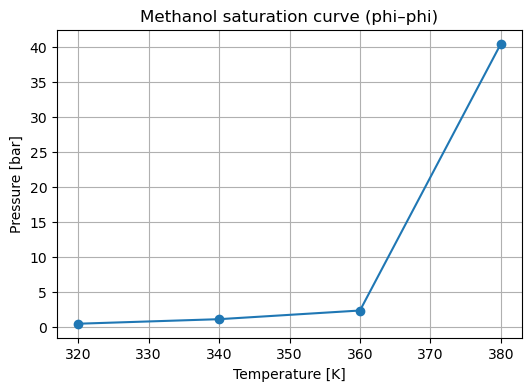

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(pt_curve['T[K]'], pt_curve['P[bar]'], marker='o')
ax.set_xlabel('Temperature [K]')
ax.set_ylabel('Pressure [bar]')
ax.set_title('Methanol saturation curve (phi–phi)')
ax.grid(True)


## Binary T–x diagram at 1 bar

Bubble and dew temperatures for methanol/ethanol over a composition grid, again using Peng–Robinson with phi–phi fugacity matching.

In [12]:
x_grid = np.linspace(0.1, 0.9, 5)
ethanol = Component.from_database("ethanol")
tx = calc.binary_Tx_diagram([methanol, ethanol], pressure=1.0, x1_grid=x_grid)
tx

,x1,Tbubble[K],y1_bubble,Tdew[K],x1_dew
0,0.1,495.12,0.1,495.12,0.1
1,0.3,495.12,0.3,495.12,0.3
2,0.5,495.12,0.5,495.12,0.5
3,0.7,479.2,0.7,479.2,0.7
4,0.9,479.2,0.9,479.2,0.9


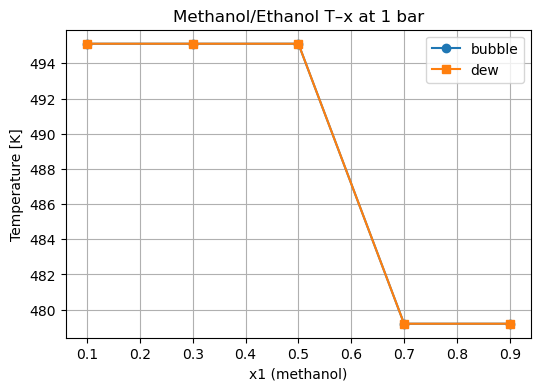

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(tx['x1'], tx['Tbubble[K]'], marker='o', label='bubble')
ax.plot(tx['x1_dew'], tx['Tdew[K]'], marker='s', label='dew')
ax.set_xlabel('x1 (methanol)')
ax.set_ylabel('Temperature [K]')
ax.set_title('Methanol/Ethanol T–x at 1 bar')
ax.legend()
ax.grid(True)
